# Lecture 17: Comparing Distributions
v.ekc

Three case studies today: jury panels in two counties and Mendel's pea plants, all answering one question: **is the data consistent with the model?** Plus a new statistic (TVD) for comparing whole distributions. 

**Today's sections:**
1. Sample proportions
2. Swain v. Alabama, revisited
3. Mendel and pea flowers
4. Alameda County jury panels
5. Total Variation Distance

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

---
## 1. Sample Proportions

About 90% of people in the population are right handed. If I randomly sample 100 people, what proportion is right handed and what proportion is left handed?

In [7]:
handedness_proportions = make_array(0.9,0.1)
sample_proportions(100,handedness_proportions)

array([ 0.89,  0.11])

---
## 2. Swain v. Alabama, Revisited

Same setup as last time: 26% eligible (26 black people), 8 observed on a panel of 100. Run it again and watch where 8 falls.

In [10]:
population_proportions = make_array(.26, .74)
population_proportions

array([ 0.26,  0.74])

In [13]:
sample_proportions(100, population_proportions)

array([ 0.29,  0.71])

Wrap the draw in a function that returns just the proportion of Black men:

In [14]:
def panel_proportion():
    return sample_proportions(100, population_proportions).item(0)

In [15]:
panel_proportion()

0.25

Simulate 10,000 panels and mark the observed 8 in red:

In [16]:
panels = make_array()

for i in np.arange(10000):
    new_panel = panel_proportion() * 100
    panels = np.append(panels, new_panel)

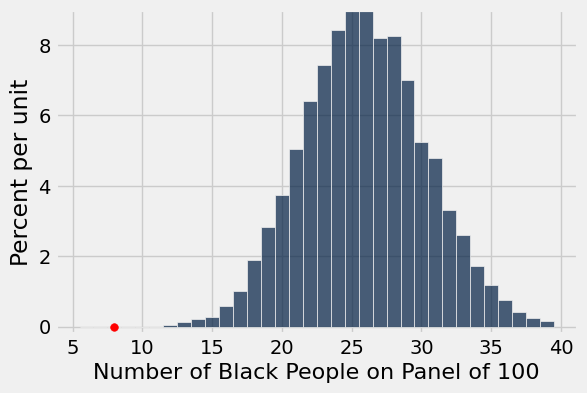

In [18]:
Table().with_column(
    'Number of Black People on Panel of 100', panels
).hist(bins=np.arange(5.5,40.))

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

---
## 3. Mendel and Pea Flowers 🌸

![Sweet peas: neither purple or white lol](sweet_peas.jpg)

Mendel's genetic model predicts 75% purple-flowering plants. He grew 929 plants and observed 709 purple (76.3%). Close to 75, but *how close is close enough?* The assessment steps:

> **Steps in assessing a model:**
> 1. choose a statistic (here: |sample % purple − 75|, so big values = bad for the model)
> 2. simulate the statistic under the model
> 3. compare the observed statistic to the simulation.

In [19]:
## Mendel had 929 plants, of which 709 had purple flowers
observed_purples = 709 / 929
observed_purples

0.7631862217438106

In [20]:
predicted_proportions = make_array(.75, .25)
sample_proportions(929, predicted_proportions)

array([ 0.75457481,  0.24542519])

Wrap the draw into the step-one statistic, the sample percent of purple:

In [21]:
def purple_flowers():
    return sample_proportions(929, predicted_proportions).item(0) * 100

In [22]:
purple_flowers()

73.6275565123789

Step two: simulate 10,000 samples grown under Mendel's model:

In [23]:
purples = make_array()

for i in np.arange(10000):
    new_purple = purple_flowers()
    purples = np.append(purples, new_purple)

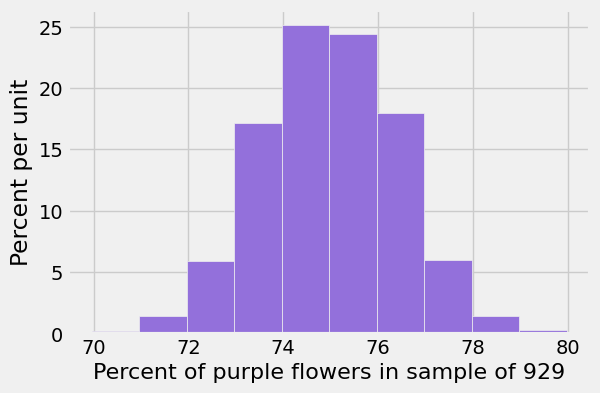

In [26]:
Table().with_column('Percent of purple flowers in sample of 929', purples).hist(facecolor='mediumpurple')

Step three: switch to the discrepancy |sample % - 75| and mark Mendel's observed value in red:

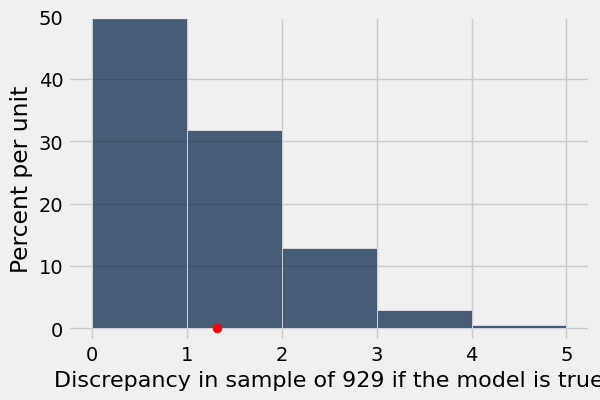

In [27]:
# Plot statistic
Table().with_column('Discrepancy in sample of 929 if the model is true', abs(purples- 75)).hist(bins = make_array(0,1,2,3,4,5))
plots.ylim(-0.02, 0.5)
plots.scatter(abs(observed_purples * 100 - 75), 0, color='red', s=40);

> **Verdict for Mendel:** the observed discrepancy (about 1.3 percentage points) sits comfortably inside the simulated distribution, the data are **consistent** with his model. Note the contrast with Swain: same recipe, opposite conclusion.

### Try It 1: Mendel's second experiment 😊

Mendel's model also predicted 75% **round** seeds. In one experiment he grew 7,324 seeds and observed 5,474 round.

1. What percent of Mendel's seeds were round?

2. Run the assessment: simulate 10,000 samples of 7,324 seeds under the 75/25 model and draw the histogram of the sample percent of round seeds.

3. Verdict: is 5,474 out of 7,324 consistent with the model?

In [ ]:
# 1. observed percent round


In [ ]:
# 2. simulate under the model


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The recipe transfers: new numbers, same three steps.*

```python
# 1.
observed_round = 5474 / 7324 * 100
observed_round

# 2.
def round_seeds():
    return sample_proportions(7324, make_array(0.75, 0.25)).item(0) * 100

round_percents = make_array()
for i in np.arange(10000):
    round_percents = np.append(round_percents, round_seeds())
Table().with_column('Percent round in sample of 7324', round_percents).hist()
```

*3. The observed 74.74% sits well inside the simulated pile (roughly 73.5 to 76.5), so this experiment is also consistent with the model.*

</details>

---
## 4. Alameda County Jury Panels

A 2010 ACLU study of 1,453 panelists across 11 felony trials in Alameda County. Now the model involves **five** ethnicity categories at once, one number per category won't do.

In [28]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian', 'Black', 'Latino', 'White', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.12, 0.54, 0.01),
    'Panels', make_array(0.26, 0.08, 0.08, 0.54, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian,0.15,0.26
Black,0.18,0.08
Latino,0.12,0.08
White,0.54,0.54
Other,0.01,0.04


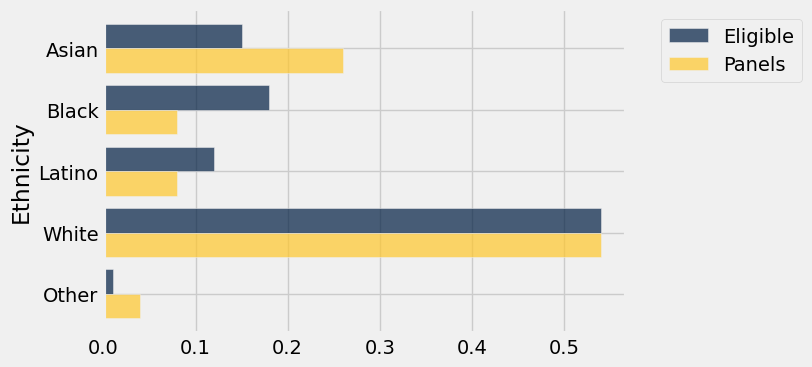

In [29]:
jury.barh('Ethnicity')

The model is the Eligible distribution. Simulate one panel draw of 1,423 people:

In [30]:
# Under the model, this is the true distribution of people
# from which the jurors are randomly sampled
model = make_array(0.15, 0.18, 0.12, 0.54, 0.01)

In [31]:
# Let's simulate a random draw of 1423 jurors from this distribution
simulated = sample_proportions(1423, model)
simulated

array([ 0.15319747,  0.19184821,  0.13492621,  0.509487  ,  0.01054111])

Put the simulated draw next to reality, in table form and in bars:

In [32]:
# The actual observed distribution (Panels) looks quite different
# from the simulation -- try running this several times to confirm!
jury_with_simulated = jury.with_column('Simulated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simulated
Asian,0.15,0.26,0.153197
Black,0.18,0.08,0.191848
Latino,0.12,0.08,0.134926
White,0.54,0.54,0.509487
Other,0.01,0.04,0.0105411


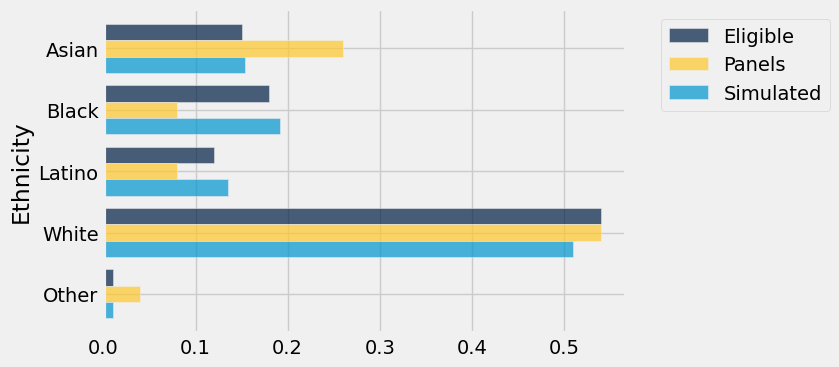

In [33]:
jury_with_simulated.barh('Ethnicity')

### Distance Between Distributions

In [34]:
#  In the Mendel model from before, the difference between observed white/purple
# and their expected values (25%/75%) was our statistic.
#
# In this case, we need to understand how each of the 5 categories
# differ from their expected values according to the model.

diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian,0.15,0.26,0.11
Black,0.18,0.08,-0.1
Latino,0.12,0.08,-0.04
White,0.54,0.54,0
Other,0.01,0.04,0.03


### Try It 2: Reading the gaps 😊

1. Sort `jury_with_difference` to find the most **over**represented group on the panels, relative to eligibility.

2. Compute the sum of the `Difference` column. Why does that number make a lousy distance measure?

3. How could you fix it? (Then peek at the next section header. 😉)

In [ ]:
# 1. most overrepresented


In [ ]:
# 2. sum of the differences


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The positives and negatives cancel perfectly, and that is the whole problem.*

```python
# 1.
jury_with_difference.sort('Difference', descending=True)

# 2.
sum(jury_with_difference.column('Difference'))
```

*3. Both distributions sum to 1, so the differences always sum to (essentially) 0: overcounts exactly cancel undercounts. Taking absolute values before summing fixes the cancellation, and that is exactly what TVD does.*

</details>

---
## 5. Total Variation Distance

**TVD** boils the difference between two whole distributions down to one number: sum the absolute differences, divide by 2. Result: the fraction of the population that would have to change categories to match.

### 📋 Reference Table

| Code | What it does |
|---|---|
| `abs(dist1 - dist2)` | category-by-category gaps |
| `sum(...) / 2` | the TVD |
| TVD = 0 | identical distributions |
| TVD = 1 | completely disjoint |

In [35]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

### Try It 3: TVD by hand ✋

Suppose a bag should be 50% red, 30% blue, 20% green, but your sample came out 60% red, 25% blue, 15% green.

1. Compute the TVD with pencil first, then check yourself with the `tvd` function.

In [ ]:
# 1. tvd of (0.5, 0.3, 0.2) vs (0.6, 0.25, 0.15)


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Gaps: 0.1 + 0.05 + 0.05 = 0.2 → divide by 2 → 0.1.*

```python
# 1.
tvd(make_array(0.5, 0.3, 0.2), make_array(0.6, 0.25, 0.15))   # 0.1
```

</details>

In [36]:
# The TVD of our observed data (Panels) from their expected values
# assuming the model is true (Eligible)
obsvd_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
obsvd_tvd

0.14000000000000001

In [37]:
# The TVD of a model simulation from its expected values
tvd(sample_proportions(1423, model), jury.column('Eligible'))

0.010147575544623994

Now 10,000 simulated TVDs, and the observed one on the same picture:

In [38]:
def simulated_tvd():
    return tvd(sample_proportions(1423, model), model)

tvds = make_array()

num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

Observed TVD: 0.14


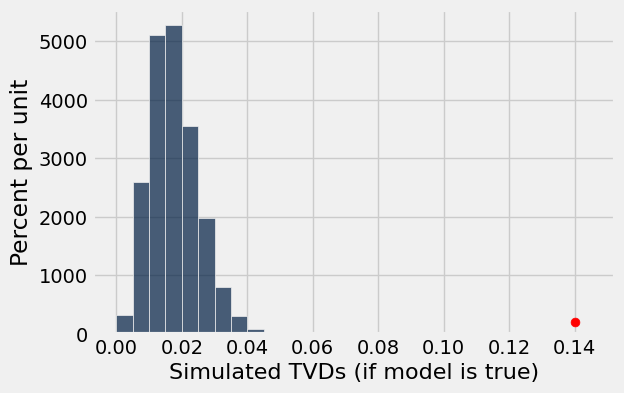

In [48]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, .15, .005)

Table().with_column(title, tvds).hist(bins = bins)
plots.scatter(obsvd_tvd, 2, color='red', s=40)
print('Observed TVD: ' + str(obsvd_tvd))

> **Read the result:** the observed TVD (~0.14) is far beyond anything the model produces (~0.02 and under). Same conclusion as Swain, now in five-category form: these panels don't look like random draws from the eligible population.

---
> **Today's takeaway:** the model-assessment recipe is universal: choose a statistic (a proportion, a discrepancy, a TVD), simulate it under the model, and see where the data falls. Homework 6 uses TVD exactly this way.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — TVD test
```python
def tvd(d1, d2):
    return sum(abs(d1 - d2)) / 2

def one_sim():
    return tvd(sample_proportions(n, model), model)
```